In [2]:
from pathlib import Path
import json
import pandas as pd

file_path = Path("../../../benchmark/data/track2/train.jsonl")

df = pd.read_json(file_path, lines=True)
print(df.head())

                                         instruction
0  I have got to list the damn payment methods, h...
1  I have got to see the refund current status, I...
2               I need to lodge a consumer complaint
3         how could I report trfoubles with payment?
4      is it possible toorder from {{Delivery City}}


In [3]:
from sentence_transformers import SentenceTransformer, util

model = SentenceTransformer('all-MiniLM-L6-v2')

emb1 = model.encode("I want assistance to send feedback for your services")
emb2 = model.encode("i want assistance to reset my profile password")

similarity = util.cos_sim(emb1, emb2)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8389.75it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
print(similarity)

tensor([[0.2281]])


In [5]:
emb1 = model.encode("want assistance send feedback services")
emb2 = model.encode("want assistance reset profile password")

similarity = util.cos_sim(emb1, emb2)
print(similarity)

tensor([[0.2306]])


In [6]:
emb1 = model.encode("want assistance send feedback services")
emb2 = model.encode("Send feedback product")

similarity = util.cos_sim(emb1, emb2)
print(similarity)

tensor([[0.6950]])


### Bert

In [ ]:
from transformers import AutoTokenizer, AutoModel
import torch

tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')
model = AutoModel.from_pretrained('distilbert-base-uncased')

emb1 = "want apples and banana"
emb2 = "return product"
inputs = tokenizer(emb1, return_tensors='pt')
inputs_2 = tokenizer(emb2, return_tensors='pt')

with torch.no_grad():
    outputs = model(**inputs)
    outputs_2 = model(**inputs_2)
    
emb_1 = outputs.last_hidden_state.mean(dim=1)  # simple mean pooling
emb_2 = outputs_2.last_hidden_state.mean(dim=1)  # simple mean pooling

similarity = util.cos_sim(emb_1, emb_2)
print(similarity)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11509.85it/s]
DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


tensor([[0.6409]])


## Save embeddings and do clustering

In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel

# 1. Load dataset
file_path = Path("../../../benchmark/data/track2/train.jsonl")
df = pd.read_json(file_path, lines=True)

# 2. Initialize models
# MiniLM SBERT
miniLM_model = SentenceTransformer('all-MiniLM-L6-v2')

# Original BERT
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased')

# 3. Function for raw BERT sentence embeddings
def bert_sentence_embedding(texts, tokenizer, model, device='cpu'):
    model.to(device)
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
            inputs = {k: v.to(device) for k,v in inputs.items()}
            outputs = model(**inputs)
            
            # Mean pooling over token embeddings
            token_embeddings = outputs.last_hidden_state  # [1, seq_len, hidden_dim]
            attention_mask = inputs['attention_mask'].unsqueeze(-1).expand(token_embeddings.size()).float()
            sentence_emb = torch.sum(token_embeddings * attention_mask, dim=1) / torch.clamp(attention_mask.sum(dim=1), min=1e-9)
            embeddings.append(sentence_emb.cpu().numpy()[0])
    
    return embeddings

# 4. Generate embeddings in batches
batch_size = 64

# MiniLM embeddings
miniLM_embeddings = []
for i in range(0, len(df), batch_size):
    batch_texts = df['instruction'].iloc[i:i+batch_size].tolist()
    batch_emb = miniLM_model.encode(batch_texts, convert_to_tensor=False)
    miniLM_embeddings.extend(batch_emb)

# BERT embeddings
bert_embeddings = bert_sentence_embedding(df['instruction'].tolist(), bert_tokenizer, bert_model, device='cpu')

# 5. Add embeddings as new columns
df['embedding_miniLM'] = miniLM_embeddings
df['embedding_bert'] = bert_embeddings

# Optional: string representation for CSV
df['embedding_miniLM_str'] = [e.tolist() for e in miniLM_embeddings]
df['embedding_bert_str'] = [e.tolist() for e in bert_embeddings]

# 6. Save the DataFrame
# df.to_csv("train_miniLM_bert_embeddings.csv", index=False)
np.save("train_miniLM_embeddings.npy", np.array(miniLM_embeddings))
np.save("train_bert_embeddings.npy", np.array(bert_embeddings))
df.to_pickle("train_miniLM_bert_embeddings.pkl")

print("Embeddings from MiniLM and BERT added and saved successfully!")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6838.79it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8949.02it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls

Embeddings from MiniLM and BERT added and saved successfully!


In [ ]:
import numpy as np
import faiss
import random

# Load embeddings and instructions
miniLM_embeddings = np.load("train_miniLM_embeddings.npy").astype('float32')  # FAISS needs float32
instructions = np.load("instructions.npy", allow_pickle=True)

num_samples = miniLM_embeddings.shape[0]

# Normalize embeddings if using cosine similarity
faiss.normalize_L2(miniLM_embeddings)

# 1. Build FAISS index
d = miniLM_embeddings.shape[1]
index = faiss.IndexFlatIP(d)  # inner product = cosine similarity on normalized vectors
index.add(miniLM_embeddings)

# 2. Query k nearest neighbors
k = 20  # number of neighbors for DBSCAN-like density
distances, neighbors = index.search(miniLM_embeddings, k)

# 3. Convert cosine similarity to distance
distances = 1 - distances  # cosine distance

# 4. Simple DBSCAN-like logic: label points if neighbor distances < eps
eps = 0.3
min_pts = 5
labels = -np.ones(num_samples, dtype=int)  # initialize all as noise
cluster_id = 0

visited = np.zeros(num_samples, dtype=bool)

for i in range(num_samples):
    if visited[i]:
        continue
    visited[i] = True
    neighbor_idxs = neighbors[i][distances[i] < eps]
    if len(neighbor_idxs) < min_pts:
        continue  # noise
    labels[neighbor_idxs] = cluster_id
    cluster_id += 1

print(f"Approximate clusters found: {cluster_id}")

# 5. Sample instructions for manual inspection
samples_per_cluster = 3
for cid in range(cluster_id):
    cluster_texts = [instructions[i] for i in range(num_samples) if labels[i] == cid]
    sample_texts = random.sample(cluster_texts, min(samples_per_cluster, len(cluster_texts)))
    print(f"\nCluster {cid}:")
    for t in sample_texts:
        print("-", t)

<class 'pandas.DataFrame'>
RangeIndex: 13435 entries, 0 to 13434
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   instruction    13435 non-null  str   
 1   embedding      13435 non-null  object
 2   embedding_str  13435 non-null  object
dtypes: object(2), str(1)
memory usage: 315.0+ KB


Sampled

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import torch
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModel

# 1. Load dataset
file_path = Path("../../../benchmark/data/track2/train.jsonl")
df = pd.read_json(file_path, lines=True)

# 1b. Randomly sample 2000 entries
df_sample = df.sample(n=2000, random_state=42).reset_index(drop=True)

# 2. Initialize models
# MiniLM SBERT
miniLM_model = SentenceTransformer('all-MiniLM-L6-v2')

# Original BERT
bert_tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')
bert_model = AutoModel.from_pretrained('bert-base-uncased')

# 3. Function for raw BERT sentence embeddings
def bert_sentence_embedding(texts, tokenizer, model, device='cpu'):
    model.to(device)
    model.eval()
    embeddings = []
    
    with torch.no_grad():
        for text in texts:
            inputs = tokenizer(text, return_tensors='pt', truncation=True, padding=True)
            inputs = {k: v.to(device) for k,v in inputs.items()}
            outputs = model(**inputs)
            
            # Mean pooling over token embeddings
            token_embeddings = outputs.last_hidden_state  # [1, seq_len, hidden_dim]
            attention_mask = inputs['attention_mask'].unsqueeze(-1).expand(token_embeddings.size()).float()
            sentence_emb = torch.sum(token_embeddings * attention_mask, dim=1) / torch.clamp(attention_mask.sum(dim=1), min=1e-9)
            embeddings.append(sentence_emb.cpu().numpy()[0])
    
    return embeddings

# 4. Generate embeddings in batches
batch_size = 64

# MiniLM embeddings
miniLM_embeddings = []
for i in range(0, len(df_sample), batch_size):
    batch_texts = df_sample['instruction'].iloc[i:i+batch_size].tolist()
    batch_emb = miniLM_model.encode(batch_texts, convert_to_tensor=False)
    miniLM_embeddings.extend(batch_emb)

# BERT embeddings
bert_embeddings = bert_sentence_embedding(df_sample['instruction'].tolist(), bert_tokenizer, bert_model, device='cpu')

# 5. Add embeddings as new columns
df_sample['embedding_miniLM'] = miniLM_embeddings
df_sample['embedding_bert'] = bert_embeddings

# Optional: string representation for CSV
df_sample['embedding_miniLM_str'] = [e.tolist() for e in miniLM_embeddings]
df_sample['embedding_bert_str'] = [e.tolist() for e in bert_embeddings]

# 6. Save the DataFrame
np.save("sample_miniLM_embeddings.npy", np.array(miniLM_embeddings))
np.save("sample_bert_embeddings.npy", np.array(bert_embeddings))
df_sample.to_pickle("sample_miniLM_bert_embeddings.pkl")

print("Random 2000-sample embeddings from MiniLM and BERT saved successfully!")

/Users/reiner/Documents/GitHub/mlsys/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 9152.24it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5164.41it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.w

Random 2000-sample embeddings from MiniLM and BERT saved successfully!


In [51]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.cluster import DBSCAN
import random
from sklearn.preprocessing import normalize

# 1. Load sampled embeddings and DataFrame
miniLM_embeddings = np.load("sample_miniLM_embeddings.npy").astype('float32')
df_sample = pd.read_pickle("sample_miniLM_bert_embeddings.pkl")

instructions = df_sample['instruction'].tolist()
num_samples = miniLM_embeddings.shape[0]

# Keep track of original DataFrame indices
indices = df_sample.index.tolist()

# 2. Normalize embeddings for cosine similarity
embeddings_norm = normalize(miniLM_embeddings)  # L2 normalization

# 3. Run DBSCAN
dbscan = DBSCAN(eps=0.3, min_samples=20, metric='cosine', n_jobs=-1)
labels = dbscan.fit_predict(embeddings_norm)

# 4. Count clusters
num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"DBSCAN found {num_clusters} clusters (noise points labeled as -1)")

# 5. Sample instructions for inspection with indices
samples_per_cluster = 15
for cid in set(labels):
    if cid == -1:
        continue  # skip noise
    # get indices of points in the cluster
    cluster_idxs = [i for i in range(num_samples) if labels[i] == cid]
    # sample some points
    sampled_idxs = random.sample(cluster_idxs, min(samples_per_cluster, len(cluster_idxs)))
    print(f"\nCluster {cid}:")
    for i in sampled_idxs:
        print(f"- Index {indices[i]}: {instructions[i]}")

DBSCAN found 18 clusters (noise points labeled as -1)

Cluster 0:
- Index 50: changing information on {{Account Category}} account
- Index 440: how can i hcange to the {{Account Type}} account
- Index 671: I am trying to find information about opening a {{Account Type}} account
- Index 1239: how can i create a standard account
- Index 675: give me information about the removal of a {{Account Type}} account
- Index 1743: i do not kow how i can create a {{Account Type}} account
- Index 1978: what do i need to do to use the {{Account Category}} account
- Index 1917: I need to create a standard account
- Index 1843: create new {{Account Type}} account
- Index 506: i need information about the termination of a {{Account Type}} account
- Index 147: I want assistance deleting my {{Account Type}} account
- Index 935: correcting data on {{Account Type}} account
- Index 1056: I need information about the deletion of my {{Account Type}} account
- Index 1285: modifying information on {{Account Typ

In [18]:
ex1 = "I dont want premium account anymore switch to non premium one"
ex2 = "I wanna buy few articles"
ex3 = "I am not happy and want to file a complaint against ur company"
ex4 = "I am not happy and want to give a feedback about ur company"
ex5 = "I dont want to talk to chatbot connect me to customer support"

In [19]:
print(df_sample['instruction'].to_list()[1543])
print(df_sample['instruction'].to_list()[1785])
print(df_sample['instruction'].to_list()[1461])

help me to use the premium profile
can I change to the premium account?
I want assistance switching to the premium account


In [20]:
import numpy as np
from sklearn.preprocessing import normalize

# Assume you have new instructions
new_instructions = [
    ex1, ex2, ex3, ex4, ex5
]

# 1. Encode new instructions using the same MiniLM model
from sentence_transformers import SentenceTransformer
miniLM_model = SentenceTransformer('all-MiniLM-L6-v2')

new_embeddings = miniLM_model.encode(new_instructions, convert_to_tensor=False)
new_embeddings = np.array(new_embeddings).astype('float32')

# 2. Normalize embeddings (L2) to match training embeddings
new_embeddings_norm = normalize(new_embeddings)
embeddings_norm = normalize(miniLM_embeddings)  # make sure old embeddings are normalized too

# 3. Assign each new embedding to the nearest point in existing clusters
def assign_dbscan_cluster(new_embs, old_embs, labels):
    assigned_clusters = []
    for emb in new_embs:
        # cosine similarity = dot product (since embeddings are normalized)
        sims = old_embs.dot(emb)
        nearest_idx = np.argmax(sims)
        cluster_label = labels[nearest_idx]
        assigned_clusters.append(cluster_label)
    return assigned_clusters

predicted_clusters = assign_dbscan_cluster(new_embeddings_norm, embeddings_norm, labels)

# 4. Print results
for instr, cluster in zip(new_instructions, predicted_clusters):
    print(f"Instruction: '{instr}' -> Assigned Cluster: {cluster}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7676.28it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Instruction: 'I dont want premium account anymore switch to non premium one' -> Assigned Cluster: 17
Instruction: 'I wanna buy few articles' -> Assigned Cluster: 15
Instruction: 'I am not happy and want to file a complaint against ur company' -> Assigned Cluster: -1
Instruction: 'I am not happy and want to give a feedback about ur company' -> Assigned Cluster: 13
Instruction: 'I dont want to talk to chatbot connect me to customer support' -> Assigned Cluster: -1


eps=0.05, min_samples=2 -> 236 clusters
eps=0.05, min_samples=3 -> 63 clusters
eps=0.05, min_samples=4 -> 33 clusters
eps=0.05, min_samples=5 -> 15 clusters
eps=0.05, min_samples=10 -> 3 clusters
eps=0.05, min_samples=15 -> 2 clusters
eps=0.05, min_samples=20 -> 1 clusters
eps=0.05, min_samples=25 -> 1 clusters
eps=0.05, min_samples=30 -> 0 clusters
eps=0.08, min_samples=2 -> 284 clusters
eps=0.08, min_samples=3 -> 106 clusters
eps=0.08, min_samples=4 -> 54 clusters
eps=0.08, min_samples=5 -> 33 clusters
eps=0.08, min_samples=10 -> 7 clusters
eps=0.08, min_samples=15 -> 3 clusters
eps=0.08, min_samples=20 -> 2 clusters
eps=0.08, min_samples=25 -> 1 clusters
eps=0.08, min_samples=30 -> 1 clusters
eps=0.10, min_samples=2 -> 290 clusters
eps=0.10, min_samples=3 -> 131 clusters
eps=0.10, min_samples=4 -> 83 clusters
eps=0.10, min_samples=5 -> 47 clusters
eps=0.10, min_samples=10 -> 14 clusters
eps=0.10, min_samples=15 -> 5 clusters
eps=0.10, min_samples=20 -> 3 clusters
eps=0.10, min_sampl

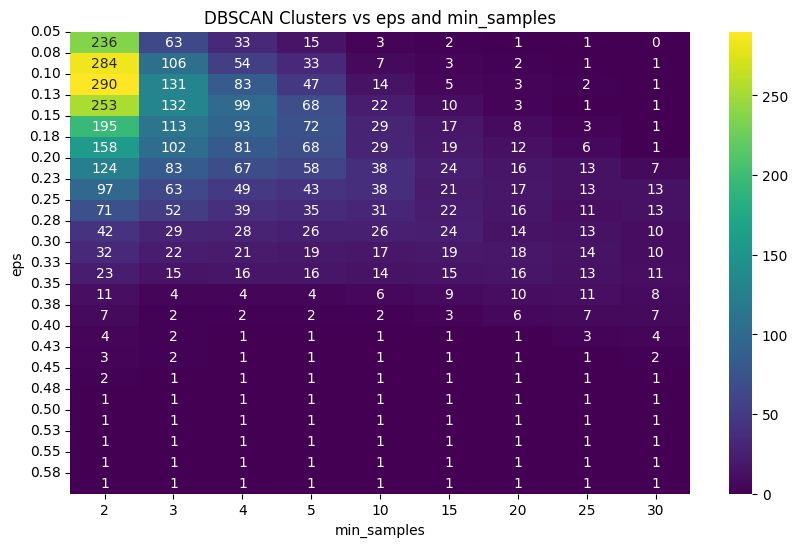

In [6]:
import numpy as np
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import normalize
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load embeddings and DataFrame
miniLM_embeddings = np.load("sample_miniLM_embeddings.npy").astype('float32')
df_sample = pd.read_pickle("sample_miniLM_bert_embeddings.pkl")
instructions = df_sample['instruction'].tolist()
num_samples = miniLM_embeddings.shape[0]

# 2. Normalize embeddings for cosine similarity
embeddings_norm = normalize(miniLM_embeddings)

# 3. Define grid for eps and min_samples
eps_values = np.arange(0.05, 0.6, 0.025)         # e.g., 0.1, 0.15, ..., 0.55
min_samples_values = [2, 3, 4, 5, 10, 15, 20, 25, 30]  # different min_samples

# 4. Grid search to store number of clusters
cluster_counts = np.zeros((len(eps_values), len(min_samples_values)))

for i, eps in enumerate(eps_values):
    for j, min_samples in enumerate(min_samples_values):
        dbscan = DBSCAN(eps=eps, min_samples=min_samples, metric='cosine', n_jobs=-1)
        labels = dbscan.fit_predict(embeddings_norm)
        num_clusters = len(set(labels)) - (1 if -1 in labels else 0)  # -1 = noise
        cluster_counts[i, j] = num_clusters
        print(f"eps={eps:.2f}, min_samples={min_samples} -> {num_clusters} clusters")

# 5. Convert results to DataFrame for plotting
cluster_df = pd.DataFrame(cluster_counts, index=eps_values, columns=min_samples_values)

# 6. Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_df, annot=True, fmt=".0f", cmap="viridis")
plt.title("DBSCAN Clusters vs eps and min_samples")
plt.xlabel("min_samples")
plt.yticks(ticks=np.arange(len(cluster_df.index)), labels=[f"{v:.2f}" for v in cluster_df.index], rotation=0)
plt.ylabel("eps")
plt.show()

In [31]:
best_eps = 0.15
best_min_samples = 2

miniLM_embeddings = np.load("sample_miniLM_embeddings.npy").astype('float32')
df_sample = pd.read_pickle("sample_miniLM_bert_embeddings.pkl")
instructions = df_sample['instruction'].tolist()
num_samples = miniLM_embeddings.shape[0]

# 2. Normalize embeddings for cosine similarity
embeddings_norm = normalize(miniLM_embeddings)

from sklearn.cluster import DBSCAN

dbscan = DBSCAN(
    eps=best_eps,
    min_samples=best_min_samples,
    metric='cosine',
    n_jobs=-1
)

labels = dbscan.fit_predict(embeddings_norm)

df_sample['cluster'] = labels

num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
num_noise = list(labels).count(-1)

print(f"Number of clusters: {num_clusters}")
print(f"Number of noise points: {num_noise}")

for cluster_id in sorted(df_sample['cluster'].unique()):
    if cluster_id == -1:
        continue  # skip noise
    
    print(f"\nCluster {cluster_id}")
    samples = df_sample[df_sample['cluster'] == cluster_id]['instruction'].head(5)
    
    for s in samples:
        print("-", s)

Number of clusters: 195
Number of noise points: 419

Cluster 0
- where to open a {{Account Category}} account?
- modify {{Account Category}} account
- changing information on {{Account Category}} account
- I need help to open a {{Account Category}} account for my daughter
- removing {{Account Category}} account

Cluster 1
- I expect a compendation of {{Currency Symbol}}{{Refund Amount}}
- i expect a reimbursxement of {{Currency Symbol}}{{Refund Amount}}
- I paid {{Currency Symbol}}{{Refund Amount}} for this purchase, I want my rebate
- i expect a reimbursxement of {{Currency Symbol}}{{Refund Amount}}
- i exepct a restitution of {{Currency Symbol}}{{Refund Amount}}

Cluster 2
- help me to use the standard profile
- could you help me to use the standard profile?
- how can I use the standard profile?
- can you help me to use the standard profile?

Cluster 3
- have a question about creating fucking {{Account Type}} accounts
- would it be possible to delete a {{Account Type}} account?
- i d

In [32]:
noise_df = df_sample[df_sample['cluster'] == -1]

for i, row in noise_df.head(10).iterrows():
    print("-", row['instruction'])
    
# for text in noise_df['instruction']:
#     print("-", text)
    
print("Total noise points:", len(noise_df))

- can uhelp me leave a damn review for a service
- I need to write an opinion about an service, how to do it?
- how can I check when my bloody product is going to arrive?
- support changing my shipping address
- I would like to request a damn refund of money
- I need helo to recover the password of my user
- create platinum account for wife
- i need help checking ur refund policy
- where can i find information about my gold account deletion
- I missed several damn articles in order {{Order Number}}
Total noise points: 419


BERT

In [ ]:
# import numpy as np
# import pandas as pd
# from pathlib import Path
# from sklearn.cluster import DBSCAN
# import random
# from sklearn.preprocessing import normalize

# # 1. Load sampled embeddings and DataFrame
# miniLM_embeddings = np.load("sample_bert_embeddings.npy").astype('float32')
# df_sample = pd.read_pickle("sample_miniLM_bert_embeddings.pkl")

# instructions = df_sample['instruction'].tolist()
# num_samples = miniLM_embeddings.shape[0]

# # Keep track of original DataFrame indices
# indices = df_sample.index.tolist()

# # 2. Normalize embeddings for cosine similarity
# embeddings_norm = normalize(miniLM_embeddings)  # L2 normalization

# # 3. Run DBSCAN
# dbscan = DBSCAN(eps=0.12, min_samples=5, metric='cosine', n_jobs=-1)
# labels = dbscan.fit_predict(embeddings_norm)

# # 4. Count clusters
# num_clusters = len(set(labels)) - (1 if -1 in labels else 0)
# print(f"DBSCAN found {num_clusters} clusters (noise points labeled as -1)")

# # 5. Sample instructions for inspection with indices
# samples_per_cluster = 15
# for cid in set(labels):
#     if cid == -1:
#         continue  # skip noise
#     # get indices of points in the cluster
#     cluster_idxs = [i for i in range(num_samples) if labels[i] == cid]
#     # sample some points
#     sampled_idxs = random.sample(cluster_idxs, min(samples_per_cluster, len(cluster_idxs)))
#     print(f"\nCluster {cid}:")
#     for i in sampled_idxs:
#         print(f"- Index {indices[i]}: {instructions[i]}")

DBSCAN found 16 clusters (noise points labeled as -1)

Cluster 0:
- Index 501: can you help me to make a customer complaint?
- Index 1445: clsoe {{Account Category}} account
- Index 1860: i have troubles changing the address
- Index 1789: I do not know how I could chat with an agent
- Index 1621: can I add a damn item to purchase {{Order Number}}?
- Index 1477: help me editingorder {{Order Number}}
- Index 1385: I do not know what I have to do to look for my bill #12588
- Index 1089: rebating  {{Refund Amount}} dollars
- Index 1616: I try to notify of issues with registrations
- Index 69: i dont know what i have to do to get my bill #85632
- Index 1223: I expect an compensation of {{Refund Amount}} dollars
- Index 869: what do i need to do to download my bill #12588
- Index 1927: showing me purchase {{Order Number}} status
- Index 307: swithcing to {{Account Category}} account
- Index 1601: canmcel order {{Order Number}}

Cluster 1:
- Index 295: could I enter a new delivery address?
- 